In [1]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,Dropout

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


In [4]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


In [5]:
emotion_names = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

Label Encoding

In [6]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])


Tokenization

In [7]:
vocab_size = 10000

tokenizer  = Tokenizer(num_words=vocab_size, oov_token="<OOV>")  #oov is out of vocabulary
tokenizer.fit_on_texts(train_df["text"])

train_sequences = tokenizer.texts_to_sequences(train_df["text"])

Converting token to sequence

In [8]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_test = tokenizer.texts_to_sequences(test_df["text"])

In [9]:
max_length = 40

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

In [10]:
model = Sequential()

model.add(
    Embedding(input_dim=vocab_size,
              output_dim=64,
              input_length=max_length)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(32, activation="relu")
)

model.add(
    Dense(6, activation="softmax")
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3166 - loss: 1.6068 - val_accuracy: 0.3262 - val_loss: 1.5750
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3760 - loss: 1.3501 - val_accuracy: 0.4031 - val_loss: 1.2317
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4333 - loss: 1.1008 - val_accuracy: 0.3997 - val_loss: 1.2370
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4653 - loss: 1.0156 - val_accuracy: 0.4672 - val_loss: 1.0910
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6444 - loss: 0.8318 - val_accuracy: 0.7575 - val_loss: 0.8158
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8410 - loss: 0.4978 - val_accuracy: 0.8384 - val_loss: 0.5768
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9009 - loss: 0.3203 - val_accuracy: 0.8403 - val_loss: 0.5362
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9281 - loss: 0.2327 - val_accuracy: 0.8700 -

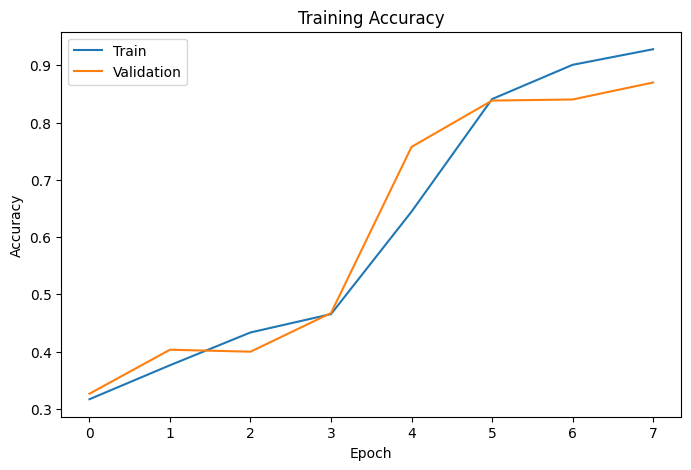

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

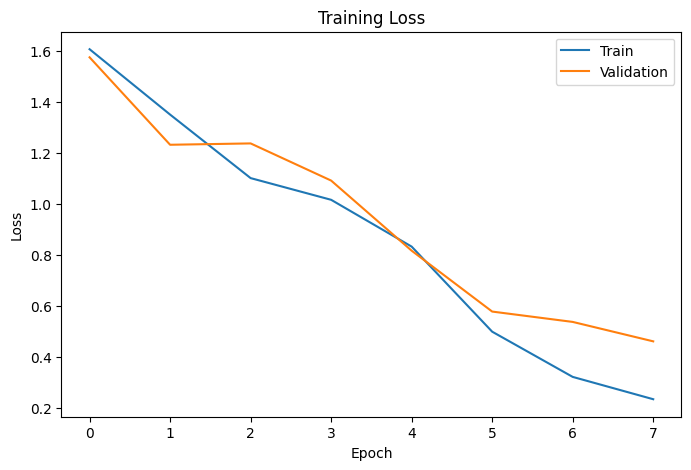

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8650 - loss: 0.4651
Test Accuracy : 0.8650000095367432


In [16]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       275
           1       0.84      0.84      0.84       224
           2       0.92      0.89      0.90       695
           3       0.61      0.74      0.66       159
           4       0.93      0.92      0.93       581
           5       0.53      0.47      0.50        66

    accuracy                           0.86      2000
   macro avg       0.78      0.79      0.78      2000
weighted avg       0.87      0.86      0.87      2000



Predicting your own sentence

In [17]:
sentence = ["I feel like killing someone "]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Emotion: love
